# 00-06 - Coordinates as Numbers

This is the bridge from the foundations series to the precepts, and its point is to make maps stop feeling like magic.

A map is not a special kind of object that requires special software. Underneath, it is a table with two number columns, and if you plot one against the other a town appears. We will do exactly that with the 92 places to eat, using nothing but the plotting we would use for any other pair of numbers.

We also meet the single most common mistake in this whole subject, which produces no error and a wrong picture.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

## Two ordinary columns

We met these in 00-05. Let us look again at what they actually contain:

In [2]:
food = pd.read_csv("data/food_table.csv")
food[["name", "lat", "lon"]].head()

,name,lat,lon
0,Metro North,40.33471,-74.65398
1,Roots Ocean Prime,40.34333,-74.65944
2,Starbucks,40.34993,-74.65946
3,Tacoria,40.35003,-74.65912
4,Maruichi Japanese Food & Deli,40.35026,-74.65827


Two number columns, `lat` and `lon`, and nothing about them is special. They are floats, like any other measurement.

**Latitude** says how far north you are, from 0 at the equator to 90 at the north pole and down to -90 at the south. **Longitude** says how far east or west, from 0 at Greenwich in London, positive going east and negative going west.

Princeton is in New Jersey, well north of the equator and well west of London, so its latitudes are around positive 40 and its longitudes around negative 74.65. Note that the minus sign is not an error and not a negative distance; it means west.

If a longitude ever loses its minus sign in your work, you have moved Princeton to somewhere near Ankara, and nothing will warn you.

## Drawing them

`plt.scatter` draws one number against another as dots. It takes the horizontal values first and the vertical values second:

Text(0.5, 1.0, '92 places to eat in Princeton')

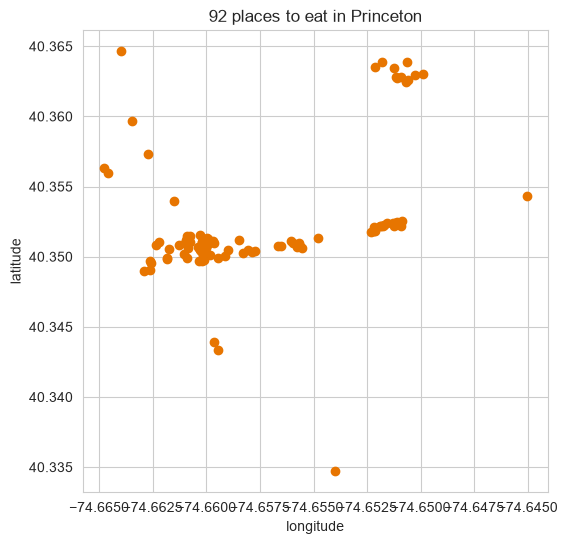

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(food["lon"], food["lat"], color="#e77500")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("92 places to eat in Princeton")

That is a map, and we did not use a mapping library to make it.

Look at what is there. A dense cluster running from lower left to upper right, which is Nassau Street and the streets around it, with a scatter of outliers. It is recognisably the shape of where you can eat in Princeton, made from nothing but two columns of numbers and a scatter plot.

This is the idea worth carrying into the precepts. Mapping libraries add coordinate systems, projections, real shapes and background imagery, and all of that matters. But underneath, a point on a map is a pair of numbers plotted against each other, and if that is all you remember you can still reason about what your code is doing.

## The mistake

Now the one that costs people an afternoon.

We say "latitude and longitude", in that order. Phone apps show latitude first. Almost every sentence you have ever read puts latitude first. So the natural thing is to plot them in that order.

Let us do the natural thing:

Text(0.5, 1.0, 'The same 92 places, with the arguments swapped')

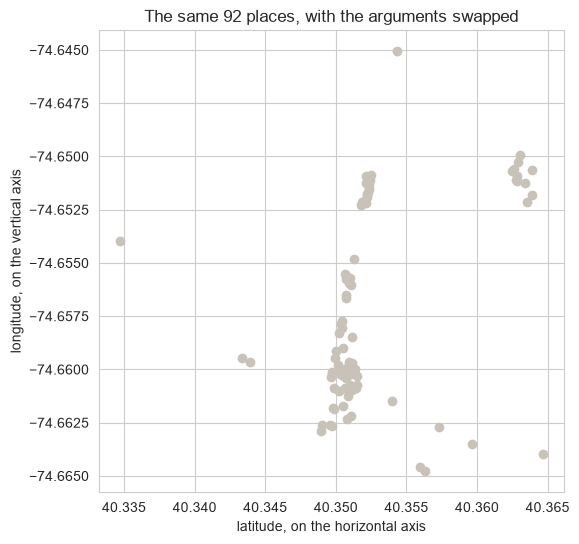

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(food["lat"], food["lon"], color="#c8c2b8")
plt.xlabel("latitude, on the horizontal axis")
plt.ylabel("longitude, on the vertical axis")
plt.title("The same 92 places, with the arguments swapped")

Princeton, rotated and flipped.

Nothing raised an error. No warning appeared. The numbers were all perfectly valid, and matplotlib did exactly what it was told. The only sign that anything is wrong is that the picture looks odd, and if you did not already know the shape of Princeton you might not notice at all.

**The rule: in code, x comes first, and x is longitude.** Say it as "lon, lat" when you write code, even though you say "latitude and longitude" out loud.

You will meet this again immediately in the precepts, where a function called `points_from_xy` builds map points and takes longitude first for exactly this reason. Now you know why, and you have seen what getting it wrong looks like.

## A degree is not a distance

One more thing before the precepts, because it explains something you would otherwise find arbitrary.

Our data spans about 0.03 degrees of latitude and 0.02 of longitude. It is tempting to treat those as distances. They are not, and the reason is that the Earth is round.

Lines of latitude are parallel, so a degree of latitude is about 111 kilometres everywhere on the planet. Lines of longitude all meet at the poles, so a degree of longitude is 111 kilometres at the equator and shrinks to nothing at the top. At Princeton's latitude of about 40 degrees it is around 85 kilometres.

Let us see what that does to our picture. Here is the same map with the axes forced to equal spacing, so that one degree is the same size in both directions:

Text(0.5, 1.0, 'Equal degrees in both directions, which is still not equal distance')

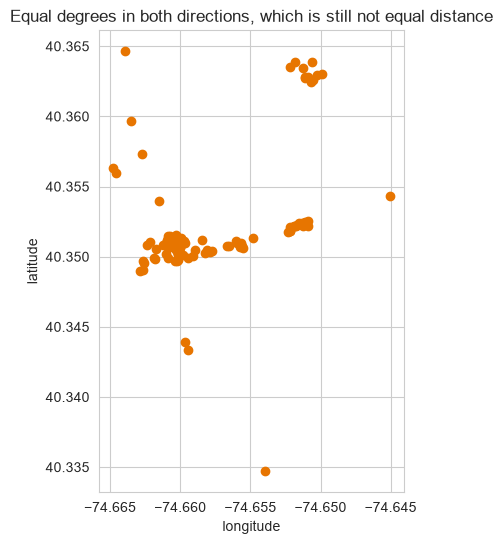

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(food["lon"], food["lat"], color="#e77500")
plt.gca().set_aspect("equal")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Equal degrees in both directions, which is still not equal distance")

Even with the axes made equal in degrees, this picture is stretched east to west compared with the ground, because those horizontal degrees are only about three quarters as wide as the vertical ones.

This is why the precepts spend a whole notebook on coordinate systems, and why any real measurement of distance or area starts by converting the data out of degrees into metres. You do not need to know how that conversion works yet. You only need to know why plain latitude and longitude cannot answer the question "how far is it".

## Check your understanding

1. Which of `(-74.65, 40.35)` and `(40.35, -74.65)` is the correct `(x, y)` pair for Princeton?
2. Nassau Hall is at longitude -74.65927 and the Dinky station at -74.6595. Which is further west?
3. You plot a town and it comes out rotated. Nothing errored. What is the most likely cause?
4. Why is a degree of latitude a safer thing to convert into kilometres than a degree of longitude?

## Where we are

You have made a map out of two number columns, you have seen what swapping them looks like, and you know why degrees are not distances.

That is the whole foundations series. You can run a notebook and understand the kernel behind it, name and combine values, call functions and read their documentation, use lists and loops, work with tables, read errors, and plot coordinates. Nothing in the precepts assumes more than that.

The last notebook in this folder, 00-08, is about working with a coding agent, and is worth reading before the first precept rather than after.

## Further resources

Nothing in this course requires anything below.

The matplotlib pyplot tutorial covers scatter plots and everything else you might want to draw: https://matplotlib.org/stable/tutorials/pyplot.html. If you would like to read ahead about coordinate systems, https://epsg.io lets you look up any of them by number, and comparing https://epsg.io/4326 with https://epsg.io/26918 shows the difference between degrees and metres.

The table used here is an OpenStreetMap extract of Princeton, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright.